In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 500)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.width', 1000)

# to make this notebook's output stable across runs
np.random.seed(42)

%matplotlib inline
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
plt.rcParams['figure.figsize'] = [20, 5]

%reload_ext autoreload
%autoreload 2

In [2]:
import geopandas as gpd
from shapely.geometry import Point, Polygon, LineString
from geopandas.tools import sjoin

## WBG Schweiz

https://genossenschaften.wbg-schweiz.ch/assets/json/data_projektportal.json

In [5]:
wbg_genossenschaften_df = pd.read_csv('./input/genossenschaften.wbg-schweiz.csv')
wbg_genossenschaften_gdf = gpd.GeoDataFrame(
    wbg_genossenschaften_df.drop(['LO', 'LA'], axis=1),
    crs={'init': 'epsg:4326'},
    geometry=[Point(xy) for xy in zip(wbg_genossenschaften_df.LO, wbg_genossenschaften_df.LA)]).to_crs({'init': 'epsg:2056'})

## Statistics BWO

In [224]:
stats_gemeinden = pd.read_csv('./input/BWO/GDE2017_GEMNUTZ_ANTEIL.csv', delimiter=';')
stats_gemeinden

,GDENR,GEMNUTZ,TOTAL_WHG,ANTEIL_GEMNUTZ
0,1,0,944,0.00
1,2,299,6104,0.05
2,3,69,2551,0.03
3,4,10,1745,0.01
4,5,51,1733,0.03
...,...,...,...,...
2235,6806,0,296,0.00
2236,6807,0,691,0.00
2237,6808,0,877,0.00
2238,6809,0,612,0.00


In [10]:
stats_gemeinden['ANTEIL_GEMNUTZ'] = stats_gemeinden['ANTEIL_GEMNUTZ']*100
stats_gemeinden[['GDENR', 'ANTEIL_GEMNUTZ']].rename({'GDENR': 'bfs', 'ANTEIL_GEMNUTZ': 'value'}, axis=1).to_csv('output/chart.csv', index=False)

## Map

Shapefiles: https://map.geo.admin.ch/?lang=en&topic=ech&bgLayer=ch.swisstopo.pixelkarte-farbe&layers=ch.swisstopo.zeitreihen,ch.bfs.gebaeude_wohnungs_register,ch.bav.haltestellen-oev,ch.swisstopo.swisstlm3d-wanderwege,ch.swisstopo-vd.amtliche-vermessung&layers_visibility=false,false,false,false,true

In [208]:
def prepare_data(city_name):
    city = gpd.read_file('./input/%s/de/Bo_BoFlaeche_A.shp' % city_name)
    city.crs = {'init': 'epsg:2056'}
    buildings = city[city['ART'] == 0]
    xmin, ymin, xmax, ymax = city.total_bounds
    genossenschaften_locations = wbg_genossenschaften_gdf.cx[xmin:xmax, ymin:ymax]
    selected = sjoin(buildings, genossenschaften_locations, op='contains')    
    return (selected, buildings)

def show_map(buildings_selected, buildings_all, *buildings_more):
    bottomPadding = 200
    xmin, ymin, xmax, ymax = buildings_all.total_bounds
    w = (xmax-xmin)/800
    h = (ymax-ymin)/800+bottomPadding
    
    fig, ax = plt.subplots(figsize=(w, h), dpi=100)
    ax.set_axis_off()
    plt.margins(0,0)
    
    buildings_all = buildings_all.drop(buildings_selected.index, errors='ignore')
    for b in buildings_more:
        buildings_all = buildings_all.drop(b.index, errors='ignore')
    buildings_all.plot(color='silver',ax=ax);
    
    buildings_selected.plot(color='blue', ax=ax)
    for b in buildings_more:
        b.plot(color='yellow', ax=ax)
    scale = gpd.GeoDataFrame([{'geometry': LineString([Point(xmin+(xmax-xmin)/2-500, ymin-bottomPadding), Point(xmin+(xmax-xmin)/2+500, ymin-bottomPadding)])}])
    scale.plot(color='silver', ax=ax)
    plt.show()
    fig.tight_layout()
    return fig

### Zurich

In [223]:
stats_gemeinden[stats_gemeinden.GDENR == 261]

,GDENR,GEMNUTZ,TOTAL_WHG,ANTEIL_GEMNUTZ
164,261,43765,238520,183500.00


In [152]:
selected_zurich, buildings_zurich = prepare_data('zurich')

In [206]:
genossenschaften_korr = gpd.GeoDataFrame.from_file('./input/zurich/genossenschaften_korr.shp')

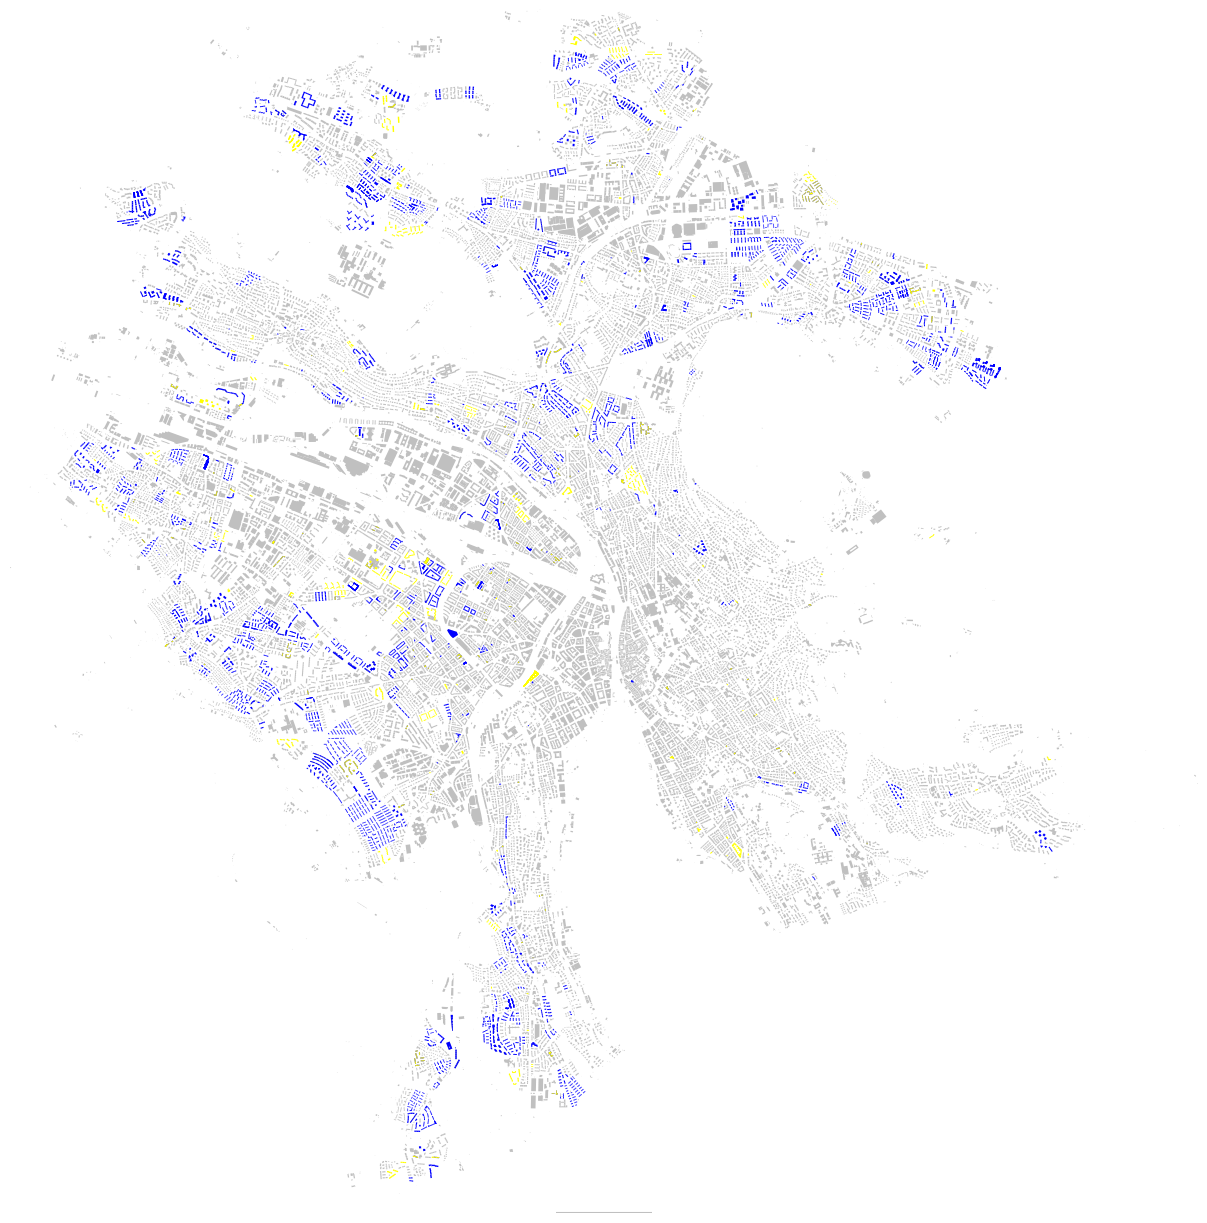

In [220]:
fig = show_map(pd.concat([selected_zurich, genossenschaften_korr], sort=False), buildings_zurich, buildings_eigentum_stadt)
fig.savefig('output/zurich.svg', bbox_inches='tight', pad_inches=0)

## Basel

In [196]:
selected_basel, buildings_basel = prepare_data('basel')

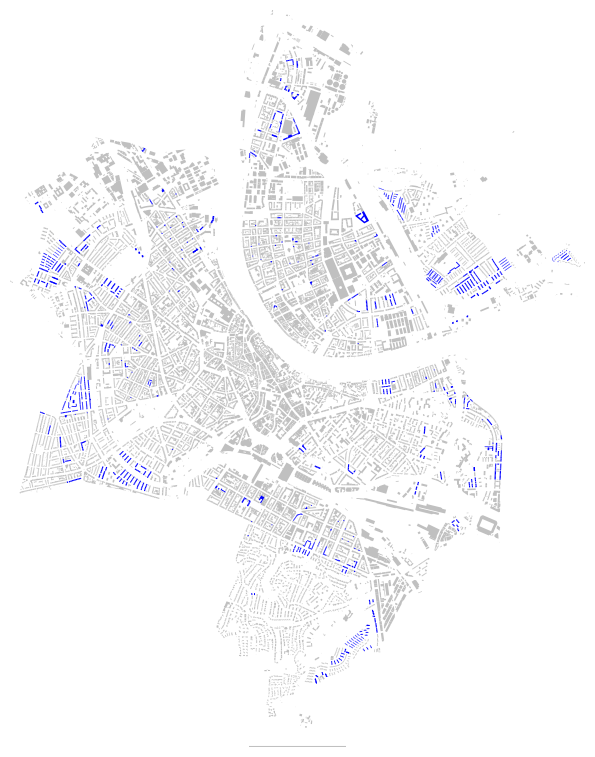

In [197]:
fig = show_map(selected_basel, buildings_basel)
fig.savefig('output/basel.png', bbox_inches='tight', pad_inches=0)

## Bern

In [199]:
selected_bern, buildings_bern = prepare_data('bern')

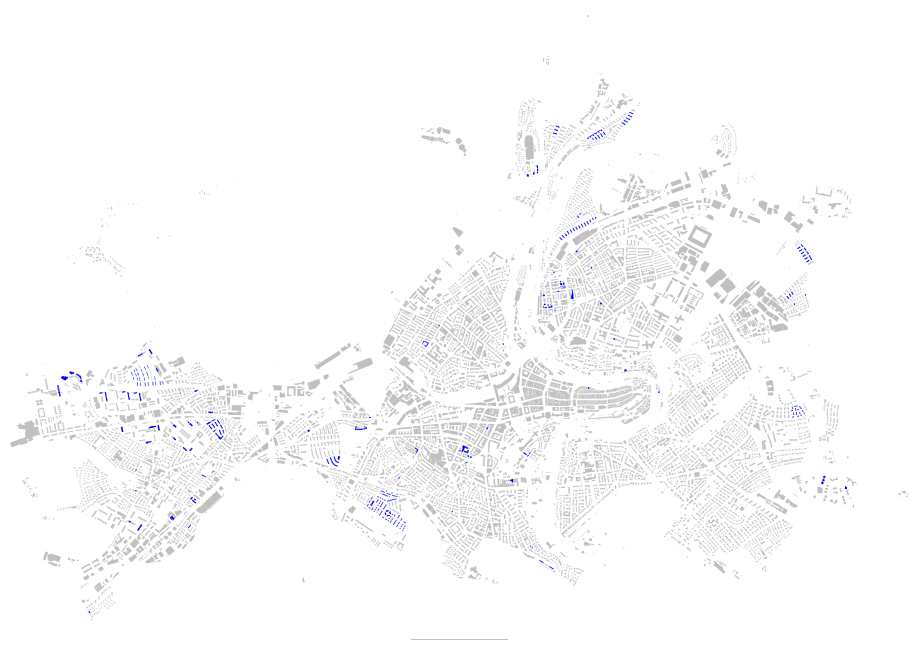

In [202]:
buildings_bern_clipped = buildings_bern.cx[2595000:, :]
fig = show_map(selected_bern, buildings_bern_clipped)
fig.savefig('output/bern.png', bbox_inches='tight', pad_inches=0)

## Genf

In [211]:
selected_geneve, buildings_geneve = prepare_data('geneve')

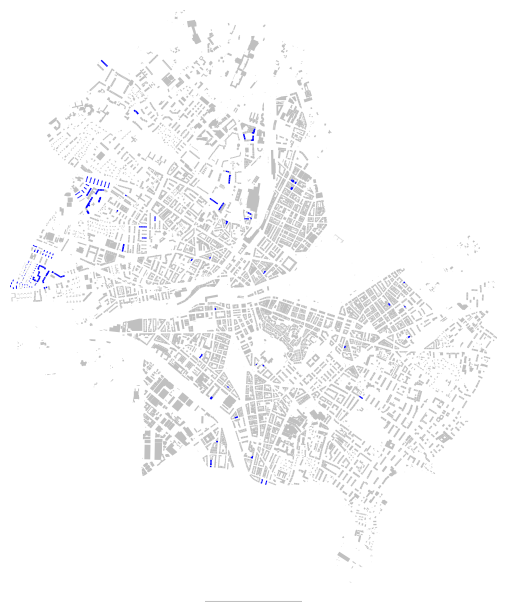

In [212]:
fig = show_map(selected_geneve, buildings_geneve)
fig.savefig('output/geneve.png', bbox_inches='tight', pad_inches=0)